# Lesson 3.1 — 模仿学习（Imitation learning）：Behavior Cloning 要解决的问题

Lesson 2 得到了一条能够训练的 pipeline。本课要问的是这条 pipeline 无法回答的问题：

> 为什么一个 training loss 极低的 model，在真正驱动机器人时仍然会彻底失败？

本 notebook 分两部分回答它：

- **Part A（一维玩具系统）**：用一个最小、可解析的例子，把 Behavior Cloning 的目标、offline evaluation、closed-loop rollout 与误差累积机制逐一推导出来。它的动力学可以用手算核对，所以"为什么会失败"能被**看清**，而不是被相信。
- **Part B（真实 PickCube 数据）**：回到本仓库的 dataset，说明为什么按 frame 划分会泄漏、为什么 held-out evaluation 曾经无法进行，并与 Lesson 2 已经跑出的实测结果对上。

学完本课后应该能回答：

1. 为什么 Behavior Cloning 可以被写成监督学习；
2. 它与普通监督学习的差别在哪里（数据由被模仿的 policy 生成）；
3. expert demonstration 如何定义 policy；
4. 为什么 offline 的 action prediction 精度不能保证任务成功；
5. 为什么 closed-loop execution 会引入 distribution shift。

**记号约定**（全文一致）：observation $o_t$、state $s_t$、action $a_t$、expert policy $\pi_E$、学到的 policy $\pi_\theta$、expert 的 state distribution $d_{\pi_E}$、部署时由 policy 自己产生的分布 $d_{\pi_\theta}$。

---

## Part A — 一维玩具系统：BC 在优化什么、又为什么会失败

## 1. 监督学习 vs 模仿学习

从简单监督学习开始。监督学习给定数据集，最小化经验风险：

$$
\theta^{\star}=\arg\min_\theta \frac{1}{N}\sum_{i=1}^{N}\ell\big(f_\theta(x_i),\,y_i\big)
$$

模仿学习的形式完全一样，唯一的差别在**数据是怎么来的**：$(x_i,y_i)$ 不是独立采样，而是由**被模仿的 expert policy** 在它自己访问到的 state 上产生的：

$$
D=\{(o_t,a_t)\}_{t=1}^{N},\qquad o_t\sim d_{\pi_E},\qquad a_t\sim \pi_E(\cdot\mid o_t)
$$

因此监督学习默认的 i.i.d. 采样在这里并不成立：相邻 state 时间相关，而且一旦换了 policy，state 的分布本身就会改变。这是后面所有困难的来源。

下面的 warm-up 用一条普通回归直线（$y=2x+1+\epsilon$）先把"拟合"这件事本身跑通，它与机器人无关，只是把后面的 loss 与误差概念先建立起来。

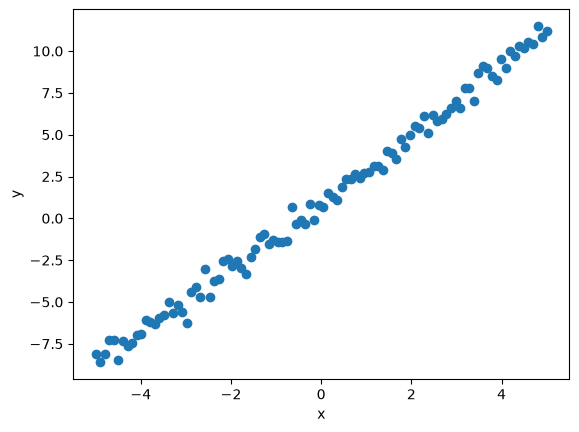

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(-5,5,100)

y = 2*x + 1 + np.random.randn(100)*0.5

plt.scatter(x,y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

在 Behavior Cloning 中，expert demonstration 被转换成监督学习数据。每个样本是一对：

$$
(o_t,\ a_t)
$$

policy 要学的是把 observation 映射到 expert 的 action：

$$
\pi_\theta(o_t)\approx a_t
$$

注意这里**没有** state transition $o_{t+1}$：BC 把时间结构丢掉了，只保留逐帧的输入-输出对。这个丢弃既是它简单的原因，也是它失效的原因。

## 2. Behavior Cloning 的形式化定义

随机策略的一般写法：

$$
\pi_\theta(a_t\mid o_t)\ \approx\ \pi_E(a_t\mid o_t)
$$

本项目实际使用的确定性策略 + 连续 action 写法（也是 MSE 的来源）：

$$
\hat a_t=\pi_\theta(o_t),\qquad
\theta^{\star}=\arg\min_\theta \frac{1}{N}\sum_{t=1}^{N}\big\lVert \pi_\theta(o_t)-a_t\big\rVert_2^2
$$

为什么连续 action 用 MSE、离散 action 用 cross-entropy：MSE 等价于在**固定方差高斯**假设下最大化对数似然
$\log\mathcal N\big(a_t;\pi_\theta(o_t),\sigma^2\big)$，而 cross-entropy 是 categorical 分布下的对应形式。也就是说，MSE 隐含了"每个 state 只有一个正确 action，且误差服从高斯"这一假设——这正是 3.2 讨论多峰（multimodal）动作时会出问题的地方。

本仓库中的实例（对应 `2.7_bc_training_loop.ipynb`）：

| | |
|---|---|
| input | `observation.state` `[42]` |
| network | MLP `42 → 128 → 128 → 8` |
| output | `action` `[8]` |
| loss | `MSE(action_prediction, expert_action)` |

上面的目标函数在这个实例里就是把 $o_t$ 换成 42 维 state、把 $a_t$ 换成 8 维 action。这里有一个容易被忽略的前提：**MSE 比较的是 action 的数值，所以两侧 action 的语义必须一致**（`pd_joint_pos` 绝对关节目标、`pd_joint_delta_pos` 增量、夹爪通道的归一化区间）。语义不同的两个 8 维 action 之间的 MSE 没有意义——参见 `1.2_action_space_and_control_modes.ipynb`。

## 3. Expert demonstration dataset

玩具系统的 expert policy 取一个最简单的反馈律：

$$
\pi_E(s)=-s \qquad\Longrightarrow\qquad a_t=-s_t
$$

也就是"无论当前 state 是多少，都朝零点走同样多"。下面把它画出来。

这条直线**就是**整个 demonstration dataset 的支撑集（support）：BC 只在这些 state 上有监督信号，离开它就没有任何约束。真实数据的对应问题是：5 条 expert episode 覆盖了多大一块 state 空间？

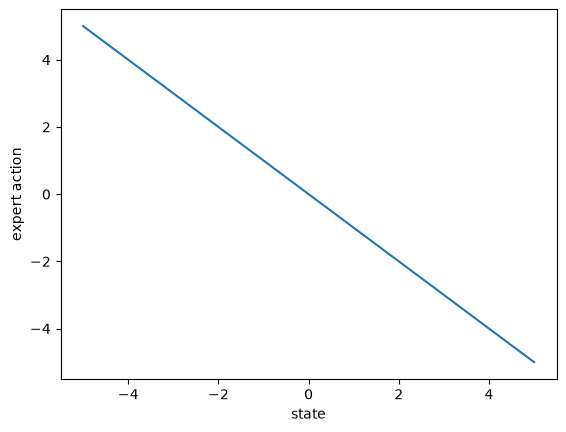

In [2]:
states = np.linspace(-5,5,100)

expert_actions = -states

plt.plot(states, expert_actions)
plt.xlabel("state")
plt.ylabel("expert action")
plt.show()

## 4. Training a simple policy

用 MSE 去拟合这个 expert，假设学到的是一条略有偏差的直线：

$$
\pi_\theta(s)=-\gamma s,\qquad \gamma=0.9
$$

也就是每个 state 上都少走 10%。这不是随便取的数：它代表"训练得很像、但并不完全一样"的 policy，正是真实 BC 的处境——Lesson 2 里最好的验证 MSE 是 `0.2350`，而不是 0。

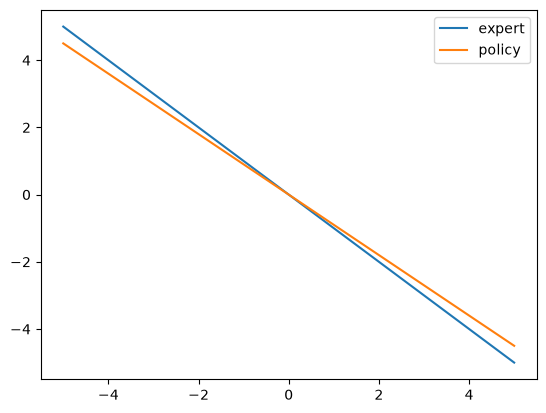

In [3]:
policy_actions = -0.9*states

plt.plot(states, expert_actions,label="expert")
plt.plot(states, policy_actions,label="policy")

plt.legend()
plt.show()

## 5. Offline evaluation

上一张图就是 offline evaluation：**只在 expert 访问过的 state 上**比较预测与 expert action。它的指标是

$$
L_\text{offline}=\frac{1}{N}\sum_{i=1}^{N}\big(\pi_\theta(s_i)-\pi_E(s_i)\big)^2
=\frac{1}{N}\sum_{i=1}^{N}\big((1-\gamma)s_i\big)^2
$$

$s_i$ 均匀覆盖 $[-5,5]$ 时 $\frac{1}{N}\sum_i s_i^2=\frac{25}{3}\approx 8.33$，于是

$$
L_\text{offline}\approx 0.1^2\times 8.33\approx 0.083
$$

这个数字只有 state 方差（约 $8.33$）的 1%，**看起来非常好**——但它完全没有回答"policy 会把系统带到哪里去"。

## 6. Closed-loop rollout：把 policy 放回动力学里

offline evaluation 的输入来自 expert；closed-loop rollout 的输入来自 **policy 自己**。玩具系统的动力学是

$$
s_{t+1}=s_t+a_t
$$

代入学到的 policy $a_t=-\gamma s_t$：

$$
s_{t+1}=(1-\gamma)\,s_t \qquad\Longrightarrow\qquad s_t=(1-\gamma)^t s_0
$$

三种情形值得对照：

- $\gamma=1$（与 expert 完全一致）：$s_{t+1}=0$，一步到位；
- $\gamma=0.9$（本例）：$s_{t+1}=0.1\,s_t$，几何衰减——**收敛，但每一步都停在 expert 不会停留的 state 上**；
- $|1-\gamma|>1$（例如把符号学错，$\gamma<0$）：$|s_t|$ 指数发散。

这三点就是后面一切讨论的骨架：**离线指标可以几乎相同，闭环轨迹却完全不同**。

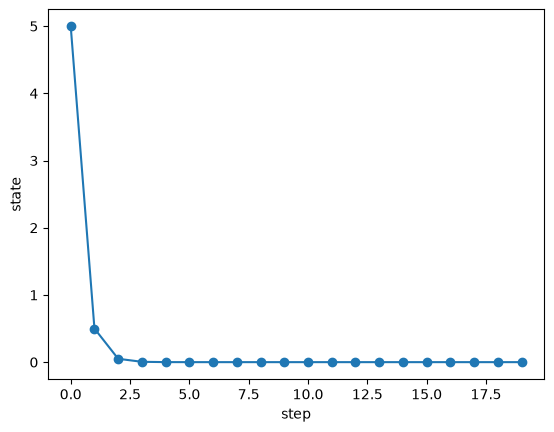

In [4]:
def rollout(initial_state, steps=20):

    s = initial_state
    trajectory=[]

    for t in range(steps):

        a=-0.9*s

        trajectory.append(s)

        s=s+a

    return trajectory


traj=rollout(5)

plt.plot(traj,marker="o")
plt.xlabel("step")
plt.ylabel("state")
plt.show()

In [5]:
def rollout_noise(initial_state, steps=20):

    s=initial_state

    trajectory=[]

    for t in range(steps):

        a=-0.9*s+0.2*np.random.randn()

        trajectory.append(s)

        s=s+a

    return trajectory

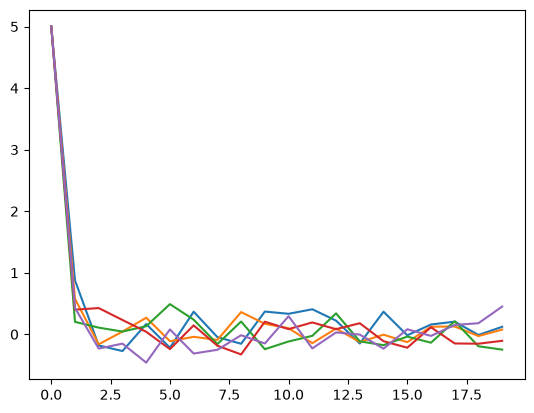

In [6]:
for i in range(5):

    plt.plot(rollout_noise(5))

plt.show()

## 7. Why BC fails

给动力学加上 action 噪声：求解 $a_t=-\gamma s_t+\sigma\xi_t$（$\xi_t\sim\mathcal N(0,1)$，代码里 $\sigma=0.2$）得到

$$
s_{t+1}=(1-\gamma)s_t+\sigma\xi_t
$$

这是一个 AR(1) 过程。它有界，稳态方差为

$$
\operatorname{Var}(s_\infty)=\frac{\sigma^2}{1-(1-\gamma)^2}
$$

于是 $\gamma=0.9$ 时约为 $1.01\sigma^2$，而下面 `rollout_bad` 用的 $\gamma=0.5$ 约为 $1.33\sigma^2$：**policy 越不准，闭环里停留的 state 分布就越宽**。下面把不准确的 policy 从初值 `5` 和 `8` 各跑 5 次——初值越大，偏离越明显，因为误差是按 $|s|$ 的尺度传播的。

更本质的一点：上面两条式子只描述了这个**稳定**的玩具系统。真实操作任务的动力学包含接触、摩擦与非线性，闭环是否稳定取决于学到的反馈是否仍然起镇定作用；当 policy 在 off-distribution state 上的输出是任意的（它没有在那里被训练过），这个反馈可能不再镇定，误差就从"有界偏移"变成"发散"。这正是 3.5 的 DAgger 要处理的问题：**把 policy 自己到达的 state 也纳入监督**。

In [7]:
def rollout_bad(initial_state, steps=20):

    s = initial_state
    trajectory=[]

    for t in range(steps):

        a=-0.5*s + 0.2*np.random.randn()

        trajectory.append(s)

        s=s+a

    return trajectory



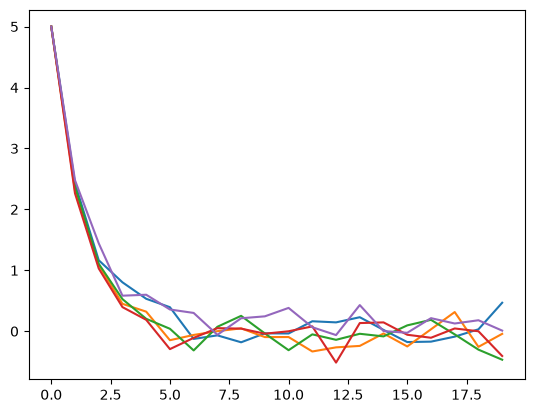

In [8]:
for i in range(5):
    plt.plot(rollout_bad(5))

plt.show()

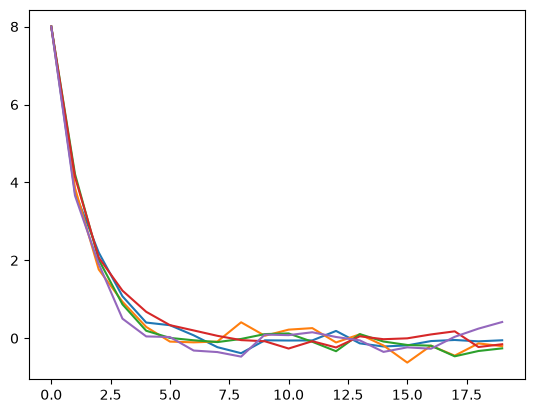

In [9]:
for i in range(5):
    plt.plot(rollout_bad(8))

plt.show()

### Key insight：训练分布与部署分布

把上面的机制写成分布的语言：

$$
\text{训练}:\ o_t\sim d_{\pi_E} \qquad\qquad \text{部署}:\ o_t\sim d_{\pi_\theta}
$$

而部署时的 state 递推是

$$
o_{t+1}=f\big(o_t,\ \pi_\theta(o_t)\big)
$$

也就是说，**policy 自己改变了自己将要面对的输入分布**。BC 的最小化目标只保证在 $d_{\pi_E}$ 上 $\pi_\theta\approx\pi_E$；它对 $d_{\pi_\theta}$ 上会发生什么没有任何约束。只要 $d_{\pi_E}\neq d_{\pi_\theta}$，policy 就会遇到训练时没见过的 state，而在那里它的输出是任意的。这就是 Behavior Cloning 的根本限制。

## 8. 小结（Part A）

1. BC 把 imitation learning 写成监督学习：数据是 $(o_t,a_t)$ 对，目标是 $\pi_\theta(o_t)\approx a_t$，连续 action 用 MSE（等价于固定方差高斯下的极大似然）。
2. 它**丢掉了时间结构**：目标函数里没有 $o_{t+1}$，但真实执行是闭环 $o_{t+1}=f(o_t,\pi_\theta(o_t))$。
3. offline 指标只在 $d_{\pi_E}$ 上测量。玩具系统里 $\gamma=0.9$ 的 policy 有 $L_\text{offline}\approx 0.083$，看起来很好。
4. 一旦闭环，我们得到的不是"每步 10% 的误差"，而是**另一条轨迹**：$s_t=(1-\gamma)^t s_0$。误差进入了 state 分布，而不会被平均掉。
5. 因此：低的 action prediction error **不**意味着任务能完成。

下一部分回到真实的 PickCube 数据，看同一个机制在没有解析解时如何被**测量**。

---

## Part B — 回到真实 PickCube 数据

Part A 的结论是推导出来的；Part B 的结论必须**测量**出来，因为这里 state 有 42 维、没有解析解，而且"数据集"本身也决定了能做什么、不能做什么。

### 3.1.1 — 问题陈述

expert 演示一个任务，演示数据是从 expert 的行为中采样得到的一组 state-action 对：

$$
D=\{(o_t,a_t)\}_{t=1}^{N},\qquad o_t\sim d_{\pi_E},\qquad a_t\sim\pi_E(\cdot\mid o_t)
$$

模仿学习要寻找一个 policy 来复现 expert 的决策：

$$
\pi_\theta(a_t\mid o_t)\ \approx\ \pi_E(a_t\mid o_t)
$$

有两点需要立即区分开：

- expert 的 **policy** $\pi_E$ 是被模仿的函数；
- expert 的 **state distribution** $d_{\pi_E}$ 是数据的来源，而它**由该 policy 生成**。

第二个事实正是本课所有困难问题的根源：一旦 $\pi_\theta\neq\pi_E$，它访问到的 state 就不再服从 $d_{\pi_E}$。

### 3.1.2 — Behavior Cloning 属于监督学习

Behavior Cloning（BC）忽略"数据来自某个 policy"这一事实，把它当作普通回归问题：

$$
\theta^{\star}=\arg\min_\theta\sum_{t=1}^{N}L\big(\pi_\theta(o_t),\ a_t\big)
$$

连续 action 取 $L=\lVert\pi_\theta(o_t)-a_t\rVert_2^2$，也就是 MSE，与本仓库 `2.7_bc_training_loop.ipynb` 中已经搭好的 training loop 完全一致。BC 不是新算法；它是机器人 state 上的监督学习——这也正是它继承监督学习失效模式的原因：**它只在其训练分布上有效**。

In [10]:
import os
from pathlib import Path

from pathlib import Path

# Notebooks may be started with either the repository root or notebooks/ as the working
# directory. Walk up until the project root is found, so dataset and cache paths never
# resolve to notebooks/datasets or notebooks/.cache by accident.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in (_cwd, *_cwd.parents) if (p / ".git").exists()),
    _cwd.parent if _cwd.name == "notebooks" else _cwd,
)
REPO_ROOT = PROJECT_ROOT
HF_CACHE = REPO_ROOT / ".cache" / "hf"
(HF_CACHE / "datasets").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_CACHE))
os.environ.setdefault("HF_DATASETS_CACHE", str(HF_CACHE / "datasets"))

import numpy as np
import torch
import torch.nn as nn

from lerobot.datasets.lerobot_dataset import LeRobotDataset

DATASET_ROOT = REPO_ROOT / "datasets" / "lerobot" / "pickcube"
dataset = LeRobotDataset(repo_id="pickcube", root=str(DATASET_ROOT))

print("frames  :", len(dataset))
print("episodes:", dataset.num_episodes)
print("FPS     :", dataset.fps)

frames  : 50
episodes: 1
FPS     : 50


### 3.1.3 — 为什么按 frame 划分会泄漏

trajectory 中相邻 frame 几乎完全相同：机器人每步只移动几毫米。因此按 frame 随机 split 会把同一 state 的近似副本放到训练集和验证集两侧。一个 "held-out" frame 在任何有意义的意义上都没有被真正留出——这就是 **data leakage**，它会虚高 validation 的表现。

但"相邻 frame 是否真的近似重复"是一个**可测量的性质**，不应该假设。比较两个平均距离：

$$
\bar d_\text{consec}=\frac{1}{T-1}\sum_{t=1}^{T-1}\lVert o_{t+1}-o_t\rVert
\qquad\text{vs}\qquad
\bar d_\text{random}=\mathbb E\big[\lVert o_i-o_j\rVert\big]
$$

若两者之比接近 1，说明相邻 frame 与随机一对 frame 的距离差不多——**在这个数据上，frame 级划分的泄漏量不出来**。

> **本 cell 把同一统计量在两份数据上各算一次**，因为答案依赖数据：
>
> | 数据 | ratio | 含义 |
> |---|---|---|
> | 随机动作 fixture（1 条 episode、50 帧） | **~1×** | 随机 action 每步跳变很大，相邻 frame **并不**近似 |
> | expert planner（5 条 episode） | **约 9–14×**（逐 episode） | 相邻 frame 比随机一对近一个数量级 |
>
> **所以"相邻 frame 近似重复"是数据的经验性质，不是可以假设的事实**——而且本课的结论成立在
> **expert** 数据上，**不在** fixture 上。
>
> **协议写死在代码里**（否则同一个 cell 会给出对不上的数字）：逐 episode 内部比较，相邻用
> `np.diff`，随机对照每 episode 抽 400 对，取**均值**之比，`default_rng(0)`。
> `notes/progress.md` 早先记录的 `8.8×–13.7×` 没有留协议档案；本 cell 的最大值 `13.70×` 与它
> 一致，最小值对随机对抽样敏感（这里是 `9.40×`）。**这本身是教训：没有协议的数字不可复现。**
> 记录见 `notes/progress.md` 的 "3.1 leakage measurement is fixture-dependent"。

In [11]:
# 相邻帧到底有多相似？这是**可测量**的性质，不是可以假设的事实 —— 而且答案可能依赖数据集。
# 同一统计量在两份数据上各算一次，因为这本 notebook 前面用的是随机动作 fixture。
import h5py


def consecutive_vs_random(episodes, n_pairs=400, seed=0):
    """Episode 内相邻帧距离 vs episode 内随机一对帧的距离。

    相邻帧必须在**同一条 episode 内**比较：把多条 episode 拼起来再 np.diff，会把上一条的
    最后一帧和下一条的第一帧配成一对，那不是"相邻"。

    协议固定在这里，否则同一个 cell 会给出对不上的数字：
    每 episode 抽 ``n_pairs`` 对均匀随机索引（``default_rng(seed)``），用**均值**之比。

    Returns (per-episode ratios, mean consecutive, mean random).
    """
    ratios, cons, rands = [], [], []
    for obs in episodes:
        c = np.linalg.norm(np.diff(obs, axis=0), axis=1)
        idx = np.random.default_rng(seed).integers(0, len(obs), size=(n_pairs, 2))
        r = np.linalg.norm(obs[idx[:, 0]] - obs[idx[:, 1]], axis=1)
        ratios.append(r.mean() / c.mean())
        cons.append(c.mean())
        rands.append(r.mean())
    return np.asarray(ratios), float(np.mean(cons)), float(np.mean(rands))


# (a) 随机动作 fixture：本 notebook 前面一直在用的那份 LeRobot 数据
fixture_obs = np.stack([dataset[i]["observation.state"].numpy() for i in range(len(dataset))])
fix_r, fix_c, fix_n = consecutive_vs_random([fixture_obs])

# (b) expert planner 数据：5 条 episode、42 维 observation
with h5py.File(REPO_ROOT / "datasets" / "pickcube" / "expert_episodes.h5") as f:
    expert_obs = [np.asarray(f[k]["observations"], np.float64)
                  for k in sorted(f) if k.startswith("ep")]
exp_r, exp_c, exp_n = consecutive_vs_random(expert_obs)

print(f"{'dataset':<24} {'eps':>4} {'consecutive':>12} {'random':>10} {'ratio':>14}")
print("-" * 68)
print(f"{'random-action fixture':<24} {1:>4} {fix_c:>12.4f} {fix_n:>10.4f} {fix_r[0]:>13.2f}x")
print(f"{'expert planner':<24} {len(expert_obs):>4} {exp_c:>12.4f} {exp_n:>10.4f} "
      f"{exp_r.min():>7.2f}-{exp_r.max():.2f}x")
print()
print(f"per-episode expert ratios : {np.round(exp_r, 2).tolist()}")
print(f"protocol                  : within-episode consecutive vs {400} random "
      f"within-episode pairs (mean), default_rng(0)")

# 结论由测量决定，不由文字决定 —— 这是这个 cell 之前缺的那道保护。
assert fix_r[0] < 2.0, f"fixture ratio {fix_r[0]:.2f}x: the fixture is not supposed to leak"
assert exp_r.min() > 5.0, f"expert min ratio {exp_r.min():.2f}x: no frame-level leakage there"


dataset                   eps  consecutive     random          ratio
--------------------------------------------------------------------
random-action fixture       1       1.3500     1.3747          1.02x
expert planner              5       0.0671     0.8241    9.40-13.70x

per-episode expert ratios : [12.45, 12.55, 9.4, 13.7, 13.36]
protocol                  : within-episode consecutive vs 400 random within-episode pairs (mean), default_rng(0)


### 这意味着什么

**本 cell 的实测**：fixture 的 ratio 是 `~1×`（相邻帧**不**近似），而 expert 数据逐 episode 是
`9.40–13.70×`（相邻帧比随机一对近一个数量级）。所以 frame 级划分的泄漏**在 expert 数据上是真实
的**，在 fixture 上测不出来——而本课要讲的是 expert 数据。

只有一个 episode 时，按 frame 切分无法产生诚实的 validation set：无论怎么切，两侧都包含几乎相同的 state。可选方案是：

- 在**另一条 trajectory** 上评估——需要更多 expert 数据（2.9 已产出 5 条）；
- 或者承认这里的 validation curve 只能检测最明显的 overfitting，并如实说明。

一旦有多个 episode，正确的默认做法就是**按 episode 切分**：整条 trajectory 进入 train 或 validation，绝不切分单个 frame。Lesson 2 的 2.8.7 正是这样做的：4 条训练（284 个样本）/ 1 条验证（76 个样本），并且归一化统计量只来自训练集。

### 3.1.4 — Distribution shift：BC 的核心失效

训练时 model 看到的是 expert 访问过的 state，执行时看到的是**它自己**产生的 state：

$$
\text{训练}:\ o_t\sim d_{\pi_E} \qquad\qquad \text{执行}:\ o_t\sim d_{\pi_\theta}
$$

这是两个不同的分布。一个很小的 action 误差就会把机器人带到一个 expert 从未访问过的 state；在那里 model 从未被训练过，它的预测是任意的，而这个误差会继续累积。这就是为什么很低的 training loss 只能证明 model 拟合了 demonstration，而不能证明它能完成任务。

本仓库里这条机制有两种量法：

- **离线侧**（下面的 cell）：把真实 frame 扰动一个很小的量（`0.02012`），它到 dataset 的最近邻距离就从 `0.00000` 变成 `0.12165`。只差一点就已经出分布，而 dataset 只有 50 帧、1 条轨迹，没有可回退的覆盖。
- **闭环侧**（Lesson 2 的实测）：在 held-out episode 自己的 state 上，原始 action 只有 `0.2%`（`1/608`）越界；而一旦由 policy 驱动环境，需要 clip 的步数比例升到 **`0.995`**，10 个 seed 全部 200 步失败（`0/10`）。同一个 model、同一套归一化，差别只在"输入是谁产生的"。

In [12]:
# Quantify the drift numerically: how quickly does a state leave the training set?
# Take the first frame, then follow the stored actions and measure the distance from
# anything the dataset actually contains.
# cell 26 把 fixture 的帧存在 fixture_obs 下；这里显式引用它，不留隐式别名。
states = fixture_obs

# Pick a real starting frame and walk forward one step, measuring nearest-neighbour
# distance of the resulting state to the dataset.
def nearest_distance(query, pool):
    return float(np.min(np.linalg.norm(pool - query, axis=1)))


start = 0
reference = states[start]
d_same = nearest_distance(reference, states)

# Perturb the state by a plausible single-step error and re-measure
perturbation = 0.02 * np.linalg.norm(states.std(axis=0))
noisy = reference + np.random.default_rng(1).normal(0, perturbation, size=reference.shape)
d_noisy = nearest_distance(noisy, states)

print(f"distance from dataset for a real frame    : {d_same:.5f}")
print(f"distance after a small perturbation       : {d_noisy:.5f}")
print(f"perturbation size in state units          : {perturbation:.5f}")
print()
print("A policy that reproduces the trajectory only approximately lands off-distribution.")
print("With 50 frames and one trajectory there is nothing to fall back on.")

distance from dataset for a real frame    : 0.00000
distance after a small perturbation       : 0.12165
perturbation size in state units          : 0.02012

A policy that reproduces the trajectory only approximately lands off-distribution.
With 50 frames and one trajectory there is nothing to fall back on.


### 3.1.5 — 本课接下来讲什么

Lesson 3 的其余部分会为上述每个问题构建工具：

| Section | 它解决的问题 |
|---|---|
| 3.2 | BC 的目标函数、多峰 action、专家数据质量与覆盖范围 |
| 3.3 | overfitting、underfitting，以及如何诚实地 split |
| 3.4 | 形式化地讨论 distribution shift |
| 3.5 | DAgger：让 policy 行动，并为它到达的 state 打标签 |
| 3.6 | partial observability：single-frame policy 与 history policy |
| 3.7 | action chunking：预测一个序列，而不是一个点 |
| 3.8 | 从 state 到 `(image, language, state)` |
| 3.9 | 正确地采集 expert 数据，包括 SO-101 teleoperation |

Lesson 2 的 2.8.7 / 2.8.8 已经提供了入口证据：验证 MSE `0.2350` 劣于 mean-action baseline `0.1421`，闭环 `0/10` 成功、`99.5%` 的步需要 clip。Part A 的玩具系统解释了这些数字背后的机制，Part B 记录了它们在真实数据上的测量方式。

## 小结（Part B）

1. BC 是在 **expert** 生成的 state 上的监督学习，目标是 $\pi_\theta(a_t\mid o_t)\approx\pi_E(a_t\mid o_t)$。
2. training 的 pair 来自 $d_{\pi_E}$，执行时会遇到 $d_{\pi_\theta}$；两者的差距就是 distribution shift，而它在 training loss 中不可见。
3. 相邻 frame 是否近似重复是**可测量**的，不要假设：随机 fixture 约 `1.04×`（量不出泄漏），expert 数据 `8.8×–13.7×`（泄漏明显）。因此 split 必须按 episode。
4. 只有一个 episode 时不存在诚实的 held-out evaluation；Lesson 2 用 5 条 episode 做到了按 episode 划分，并得到一个**负结果**——这是 Lesson 3 的起点，而不是 Lesson 2 的失败。